In [4]:
# %load_ext autoreload
# %autoreload 2
import sys
import torch
print(f"Python path: {sys.executable}")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

Python path: C:\Users\vikas\OneDrive\Desktop\CSE_PROJ\minigrid_static_fullobs\minigrid-static-fullobs\venv\Scripts\python.exe
PyTorch version: 2.9.1+cpu
GPU available: False


In [5]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import sys
import os
import gymnasium.spaces as spaces
from types import SimpleNamespace
sys.path.append(os.getcwd())
from utils.env import make_env
from certificate import CertificateNet
from model import ACModel
from data_gen_mod import generate_transitions
import matplotlib.pyplot as plt
from minigrid.wrappers import RGBImgObsWrapper

C:\Users\vikas\OneDrive\Desktop\CSE_PROJ\minigrid_static_fullobs\minigrid-static-fullobs\venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [8]:
# def scratch():
#     V_curr = certificate(C_states)
#     policy_input = SimpleNamespace(image=C_states)
#     dist, _ , _= policy(policy_input,None)
#     probs = F.softmax(dist.logits , dim=1)
#     return 

In [9]:
import torch
import numpy as np

class Block:
    """
    Represents a rectangular region of the grid.
    Coordinates are inclusive-exclusive: [x_min, x_max) and [y_min, y_max).
    """
    def __init__(self, x_min, y_min, x_max, y_max):
        self.x_min = int(x_min)
        self.y_min = int(y_min)
        self.x_max = int(x_max)
        self.y_max = int(y_max)
        
        # Center for the Learner (Continuous)
        self.cx = (self.x_min + self.x_max) / 2.0
        self.cy = (self.y_min + self.y_max) / 2.0
        
        # Area for debugging
        self.area = (self.x_max - self.x_min) * (self.y_max - self.y_min)

def verify_abstraction(env, policy, certificate, all_blocks):
    """
    Verifies the list of abstract blocks.
    
    Logic:
    1. Iterate over each block.
    2. Check Robustness: Does Policy(cell) == Policy(center) for all cells?
    3. Check Safety: Do Certificate conditions hold for all cells?
    
    Returns:
    - kept_blocks: Blocks that are either Safe OR have Hard Violations (don't split).
    - new_blocks: Smaller blocks resulting from splits (Soft Violations).
    - hard_violations: Dictionary of tensors { "init": [...], "unsafe": [...], "decrease": [...] }
    """
    
    device = next(policy.parameters()).device
    
    kept_blocks = []
    new_blocks = []
    
    # Storage for Hard Violations (Centers that failed)
    hard_violations = {
        "init": [],
        "unsafe": [],
        "decrease": []
    }
    
    # Constants
    UNSAFE_BARRIER = 100.0 # Adjust based on your training constants
    EPSILON = 0.1          # Decrease epsilon
    SAMPLES = 10           # Samples for stochastic checking
    
    print(f"Verifying {len(all_blocks)} blocks...")
    
    for block in all_blocks:
        
        # --- 1. PREPARE BLOCK DATA ---
        
        # A. Determine Reference Action (from Center)
        # We assume the center defines the "intended" action for the whole block.
        # Note: We use the integer center cell for the policy query to be consistent with discrete grid.
        center_x_int = int(block.cx)
        center_y_int = int(block.cy)
        
        # Construct center tensor
        center_tensor = get_state_tensor(env, center_x_int, center_y_int).to(device)
        
        with torch.no_grad():
            logits_c, _, _ = policy(ObsBatch(center_tensor), None)
            target_action = dist_probs_to_action(logits_c) # Helper to get argmax
            v_center = certificate(center_tensor).item()

        # Flags
        soft_fail = False
        hard_fail = False
        
        # --- 2. ITERATE ALL CELLS IN BLOCK ---
        # We check every discrete cell (x, y) belonging to this block
        
        for x in range(block.x_min, block.x_max):
            for y in range(block.y_min, block.y_max):
                
                # SKIP OBSTACLES / BALLS (if required)
                # Assuming env.grid.get(x,y) returns None for empty, or object
                cell_obj = env.grid.get(x, y)
                
                # Ignore walls (always)
                if cell_obj is not None and cell_obj.type == 'wall':
                    continue
                
                # Ignore balls for "Next State" checks? 
                # User said: "ignore the cells containing balls since for an unsafe state there is no next state"
                # But we MUST check if the ball state itself is marked Unsafe in the certificate.
                is_ball = (cell_obj is not None and cell_obj.type == 'ball')
                
                # Create Tensor for current cell
                curr_tensor = get_state_tensor(env, x, y).to(device)
                
                with torch.no_grad():
                    # --- A. ROBUSTNESS CHECK ---
                    # Action at (x,y) must match Action at Center
                    logits_xy, _, _ = policy(ObsBatch(curr_tensor), None)
                    action_xy = dist_probs_to_action(logits_xy)
                    
                    if action_xy != target_action:
                        soft_fail = True
                        break # Stop checking this block, we need to split
                    
                    # --- B. SAFETY CHECKS ---
                    v_curr = certificate(curr_tensor).item()
                    
                    # 1. Init Condition: V(s) <= 1.0 (if s is Start State)
                    # Assuming (1,1) is start, or checking env.agent_start_pos
                    # For simple 16x16, typically a specific region is init.
                    # Here we check if the cell satisfies "Is Init".
                    if is_init_state(env, x, y): 
                        if v_curr > 1.0:
                            # VIOLATION FOUND
                            if x == center_x_int and y == center_y_int:
                                hard_violations["init"].append(center_tensor)
                                hard_fail = True # Center is bad
                            else:
                                soft_fail = True # Neighbor is bad
                            break
                    
                    # 2. Unsafe Condition: V(s) > BARRIER (if s is Unsafe/Ball)
                    # Note: User prompt implies Ball = Unsafe.
                    # Check if this specific cell is Unsafe (e.g. Lava or Ball)
                    if is_unsafe_state(env, x, y):
                        # We want V > Barrier (Safety defined as high value for unsafe)
                        # Or V <= Barrier is Violation
                        if v_curr <= UNSAFE_BARRIER:
                             if x == center_x_int and y == center_y_int:
                                hard_violations["unsafe"].append(center_tensor)
                                hard_fail = True
                             else:
                                soft_fail = True
                             break
                    
                    # 3. Decrease Condition: V(next) < V(curr)
                    # Skip if cell is Ball/Unsafe (no next state)
                    if not is_unsafe_state(env, x, y):
                        # Stochastic Check
                        v_next_sum = 0.0
                        for _ in range(SAMPLES):
                            env.load_state_from_tensor(curr_tensor)
                            obs, _, _, _, _ = env.step(action_xy)
                            next_tensor = torch.tensor(obs['image'], device=device).unsqueeze(0).float()
                            v_next_sum += certificate(next_tensor).item()
                        
                        v_next_avg = v_next_sum / SAMPLES
                        
                        # We want: v_next + eps <= v_curr
                        # Violation: v_next + eps > v_curr
                        if v_next_avg + EPSILON > v_curr:
                             if x == center_x_int and y == center_y_int:
                                hard_violations["decrease"].append(center_tensor)
                                hard_fail = True
                             else:
                                soft_fail = True
                             break
            
            if soft_fail or hard_fail:
                break

        # --- 3. DECISION LOGIC ---
        
        if hard_fail:
            # Center is bad. Splitting won't fix the center.
            # Keep block (so we don't lose the region), learner will fix center next iter.
            kept_blocks.append(block)
            
        elif soft_fail:
            # Center is good, but corners/neighbors are bad.
            # Abstraction is too coarse. Split!
            
            # Check if block is divisible
            width = block.x_max - block.x_min
            height = block.y_max - block.y_min
            
            if width <= 1 and height <= 1:
                # 1x1 block cannot split. Treat soft fail as hard fail (Safety Critical)
                # This happens if a neighbor of a 1x1 (which doesn't exist) fails... 
                # Actually, in 1x1 loop, x==center. So soft_fail is impossible in 1x1.
                # It would always be hard_fail.
                kept_blocks.append(block) 
            else:
                # Perform Quad Split
                subs = split_block(block)
                new_blocks.extend(subs)
                
        else:
            # All checks passed
            kept_blocks.append(block)

    # Convert lists to tensors
    for key in hard_violations:
        if len(hard_violations[key]) > 0:
            hard_violations[key] = torch.cat(hard_violations[key])
        else:
            hard_violations[key] = torch.tensor([], device=device)

    return kept_blocks, new_blocks, hard_violations


# --- HELPER FUNCTIONS ---

def split_block(b):
    """ Splits a block into up to 4 sub-blocks (Quadtree style). """
    # Calculate midpoints (Discrete split)
    # If width is 3 (1,2,3), mid is 1+3//2 = 2. Splits: [1,2), [2,4) -> size 1 and 2.
    mid_x = (b.x_min + b.x_max) // 2
    mid_y = (b.y_min + b.y_max) // 2
    
    subs = []
    
    # Create 4 potential children (Top-Left, Top-Right, Bot-Left, Bot-Right)
    # 1. x_min -> mid_x, y_min -> mid_y
    if mid_x > b.x_min and mid_y > b.y_min:
        subs.append(Block(b.x_min, b.y_min, mid_x, mid_y))
        
    # 2. mid_x -> x_max, y_min -> mid_y
    if b.x_max > mid_x and mid_y > b.y_min:
        subs.append(Block(mid_x, b.y_min, b.x_max, mid_y))
        
    # 3. x_min -> mid_x, mid_y -> y_max
    if mid_x > b.x_min and b.y_max > mid_y:
        subs.append(Block(b.x_min, mid_y, mid_x, b.y_max))
        
    # 4. mid_x -> x_max, mid_y -> y_max
    if b.x_max > mid_x and b.y_max > mid_y:
        subs.append(Block(mid_x, mid_y, b.x_max, b.y_max))
        
    return subs

def dist_probs_to_action(logits):
    """ Helper to get integer action from logits """
    probs = torch.softmax(logits, dim=1)
    return probs.argmax(dim=1).item()

def get_state_tensor(env, x, y):
    """ Creates the tensor representation for cell (x,y) """
    # Assuming standard MiniGrid 3-channel encoding or similar
    # You might need to adjust this to match your ObsBatch logic
    # Here we mock it by loading state into env and getting obs
    # WARNING: This is slow. Optimally, construct tensor directly if possible.
    env.agent_pos = (x, y)
    env.agent_dir = 0 # Assume direction 0 for static checks? 
                      # Or loop directions? Usually abstraction ignores direction or assumes worst case.
    obs = env.gen_obs() 
    return torch.tensor(obs['image'], dtype=torch.float32).unsqueeze(0)

class ObsBatch:
    def __init__(self, tensor):
        self.image = tensor

# --- STATE CHECK HELPERS (Adjust to your Env logic) ---

def is_init_state(env, x, y):
    # Example: Top-Left corner is start
    return (x == 1 and y == 1)

def is_unsafe_state(env, x, y):
    # Check for Ball or specific Unsafe object
    cell = env.grid.get(x, y)
    if cell is not None and cell.type == 'ball':
        return True
    return False

In [10]:
class ObsBatch:
    def __init__(self, tensor):
        self.image = tensor

In [11]:
def train_learner(env, policy, certificate, optimizer_cert, optimizer_policy, 
                  # Counterexample Centers (Hard Violations found by Verifier)
                  Centers_init_CE, Centers_unsafe_CE, Centers_decrease_CE, 
                  # All Block Centers (The "Base" dataset to prevent forgetting)
                  Centers_init_All, Centers_unsafe_All, Centers_decrease_All, 
                  iteration):
    """
    The LEARNER Module (Abstraction Refinement Version)
    Minimizes Eq (3) + Lipschitz Loss on Block Centers.
    
    NOTE: All input tensors MUST be the Centers of the blocks. 
    We do NOT train on random points anymore; only on the representatives (centers).
    """
    policy.train()
    certificate.train()
    
    # --- Hyperparameters ---
    EPOCHS_PER_ITER = 2000
    WARMUP_EPOCHS = 600       # Policy stays frozen until this epoch
    BATCH_SIZE_BASE = 200     # Sample from All Centers
    BATCH_SIZE_CE = 100       # Sample from Hard Violations (Weighted higher)
    SAMPLES_PER_STATE = 20    # Stochastic samples for expected decrease
    LAMBDA_LIP = 0.05         # Weight for Lipschitz regularization
    
    print(f"\n--- Learner Loop {iteration} (Training on Block Centers) ---")
    
    for epoch in range(EPOCHS_PER_ITER):
        optimizer_cert.zero_grad()
        optimizer_policy.zero_grad()
        
        # ======================================================================
        # 1. BATCH PREPARATION (Mixing Global Centers + Hard Failures)
        # ======================================================================
        
        # --- Helper to create mixed batch ---
        def get_mixed_batch(All_Centers, CE_Centers, size_base, size_ce):
            # 1. Sample from ALL blocks (General Stability)
            if len(All_Centers) > 0:
                idx_base = torch.randint(0, len(All_Centers), (min(len(All_Centers), size_base),))
                batch_base = All_Centers[idx_base]
            else:
                batch_base = torch.tensor([], device=CE_Centers.device if len(CE_Centers) else All_Centers.device)

            # 2. Sample from Counterexamples (Focus on Hard Violations)
            if len(CE_Centers) > 0:
                idx_ce = torch.randint(0, len(CE_Centers), (min(len(CE_Centers), size_ce),))
                batch_ce = CE_Centers[idx_ce]
            else:
                batch_ce = torch.tensor([], device=batch_base.device)
                
            # Combine
            if len(batch_base) > 0 and len(batch_ce) > 0:
                return torch.cat([batch_base, batch_ce])
            elif len(batch_base) > 0:
                return batch_base
            elif len(batch_ce) > 0:
                return batch_ce
            else:
                return torch.tensor([], device=Centers_unsafe_All.device) # Empty fallback

        # Create the 3 batches of CENTERS
        batch_init = get_mixed_batch(Centers_init_All, Centers_init_CE, BATCH_SIZE_BASE, BATCH_SIZE_CE)
        batch_unsafe = get_mixed_batch(Centers_unsafe_All, Centers_unsafe_CE, BATCH_SIZE_BASE, BATCH_SIZE_CE)
        batch_decrease = get_mixed_batch(Centers_decrease_All, Centers_decrease_CE, BATCH_SIZE_BASE, BATCH_SIZE_CE)

        # ======================================================================
        # 2. CALCULATE LOSSES (On Centers)
        # ======================================================================

        # --- A. L_Init: Max(V(center) - 1, 0) ---
        if len(batch_init) > 0:
            loss_init = torch.mean(torch.relu(certificate(batch_init) - 1.0))
        else:
            loss_init = torch.tensor(0.0, device=Centers_unsafe_All.device)

        # --- B. L_Unsafe: Max(Barrier - V(center), 0) ---
        if len(batch_unsafe) > 0:
            loss_unsafe = torch.mean(torch.relu(UNSAFE_BARRIER - certificate(batch_unsafe)))
        else:
            loss_unsafe = torch.tensor(0.0, device=Centers_unsafe_All.device)

        # --- C. L_Expected & L_Policy (On Centers) ---
        loss_expected = torch.tensor(0.0, device=Centers_unsafe_All.device)
        loss_policy = torch.tensor(0.0, device=Centers_unsafe_All.device)

        if len(batch_decrease) > 0:
            # V(center)
            V_curr = certificate(batch_decrease)
            
            # Policy at Center
            policy_input = ObsBatch(batch_decrease)
            dist, _, _ = policy(policy_input, None)
            
            # [CRITICAL] Argmax Selection + LogProb Gradient Trick
            # This ensures we train the policy to select the right action AT THE CENTER
            intended_actions = dist.probs.argmax(dim=1)
            action_log_probs = dist.log_prob(intended_actions)
            
            # --- Simulation ---
            # We take the action chosen at the center, and step it.
            actions_np = intended_actions.cpu().numpy()
            next_list = []
            
            # Loop for stochastic sampling
            for i in range(len(batch_decrease)):
                center_tensor = batch_decrease[i]
                action = actions_np[i]
                for _ in range(SAMPLES_PER_STATE):
                    env.load_state_from_tensor(center_tensor)
                    obs, _, _, _, _ = env.step(action)
                    next_list.append(obs['image'])
            
            huge_batch_np = np.stack(next_list)
            huge_batch = torch.tensor(huge_batch_np, dtype=torch.float32, device=Centers_unsafe_All.device)
            
            # --- Violation Calculation ---
            v_next_all = certificate(huge_batch).view(-1)
            v_next_reshaped = v_next_all.view(len(batch_decrease), SAMPLES_PER_STATE)
            expected_V_next = v_next_reshaped.mean(dim=1, keepdim=True)
            
            # Requirement: V(next) < V(center) - eps
            violation = expected_V_next + EPSILON - V_curr
            
            # Loss 1: Certificate (Minimize Violation at Center)
            loss_expected = torch.mean(torch.relu(violation))
            
            # Loss 2: Policy (Punish Center Action if it leads to violation)
            loss_policy = torch.mean(torch.relu(violation).detach() * action_log_probs)

        # --- D. L_Lipschitz (Smoothness Requirement) ---
        # Forces networks to be smooth so large blocks are valid
        loss_lip, _, _ = get_lipschitz_loss(policy, certificate, lambda_lip=LAMBDA_LIP)

        # ======================================================================
        # 3. BACKPROPAGATION
        # ======================================================================
        
        # Total Loss for Certificate
        total_loss_cert = loss_init + loss_unsafe + (100.0 * loss_expected) + loss_lip
        
        # Backprop Certificate
        total_loss_cert.backward()
        optimizer_cert.step()

        # Update Policy ONLY after Warmup
        if epoch >= WARMUP_EPOCHS:
            PUNISHMENT_FACTOR = 50.0 
            total_loss_policy = (loss_policy * PUNISHMENT_FACTOR) + loss_lip
            
            total_loss_policy.backward()
            optimizer_policy.step()
        else:
            optimizer_policy.zero_grad() 

        # ======================================================================
        # 4. LOGGING & SAVING
        # ======================================================================
        if epoch % 200 == 0:
            # Logging Weights
            try:
                pol_w = policy.actor[-1].weight
            except:
                pol_w = list(policy.parameters())[0]
            p_mean = pol_w.mean().item()
            
            last_layer_weights = certificate.actor[-1].weight
            w_mean = last_layer_weights.mean().item()
            
            status_msg = "FROZEN ❄️" if epoch < WARMUP_EPOCHS else "UPDATING 🔥"
            
            print(f"  Ep {epoch} [{status_msg}] | Loss: {total_loss_cert.item():.4f} | "
                  f"Init: {loss_init.item():.4f} | "
                  f"Unsafe: {loss_unsafe.item():.4f} | "
                  f"Decr: {loss_expected.item():.4f} | "
                  f"Lip: {loss_lip.item():.4f}")
            print(f"           > Cert Mean={w_mean:.5f} | Pol Mean={p_mean:.5f}")
            
            # Save State
            checkpoint = {
                "model_state": certificate.state_dict(),
                "policy_state": policy.state_dict(),
                "optimizer_cert_state": optimizer_cert.state_dict(),
                "optimizer_policy_state": optimizer_policy.state_dict(),
            }
            torch.save(checkpoint, CERTI_PATH)
            
    return policy, certificate

In [13]:
# --- CONFIGURATION ---
ENV_NAME = "MiniGrid-Dynamic-Obstacles-16x16-v0"
MODEL_PATH = "storage/randomenv_ranreward_16_v2_feedbackmod/status.pt" 
CERTI_PATH = "certis/certificate_16x16_feedback_LV.pt"

# Paper Parameters
P_SATISFACTION = 0.90
UNSAFE_BARRIER = 1.0 / (1.0 - P_SATISFACTION) # ~100
EPSILON = 0.01
MAX_ITERATIONS = 20  # Max number of CEGIS loops
EPOCHS_PER_ITER = 500 # How long to train per loop

def main():
    # 1. Setup Universe (All possible states)
    env = make_env(ENV_NAME, seed=1)
    states, masks, agentPos, direc = generate_transitions(ENV_NAME,1)
    
    device = states.device
    all_init = states[masks["start"].to(device)]
    all_unsafe = states[masks["unsafe"].to(device)]
    all_decrease = states[masks["safe"].to(device) ]

    C_init=all_init
    ratio=0.5
    n_unsafe = int(len(all_unsafe) * ratio)
    idx_unsafe = torch.randperm(len(all_unsafe))[:n_unsafe]
    C_unsafe = all_unsafe[idx_unsafe]
    n_decrease = int(len(all_decrease) * ratio)
    idx_decrease = torch.randperm(len(all_decrease))[:n_decrease]
    C_decrease = all_decrease[idx_decrease]

    # Check if observation_space is a Box (standard for ImgObsWrapper)
    dummy_obs_space = {"image": (16, 16, 3)}

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    states = states.to(device);
    for k in masks: masks[k] = masks[k].to(device)

    # 2. Initialize Networks
    policy = ACModel(dummy_obs_space, env.action_space)
    checkpoint = torch.load(MODEL_PATH)
    policy.load_state_dict(checkpoint["model_state"])
    certificate = CertificateNet(dummy_obs_space)
    # optimizer = optim.Adam(list(certificate.parameters()), lr=0.0003)
    optimizer_cert = torch.optim.Adam(certificate.parameters(), lr=1e-3)
    optimizer_policy = torch.optim.Adam(policy.parameters(), lr=1e-4)
    # checkpoint = torch.load(CERTI_PATH)
    # policy.load_state_dict(checkpoint["policy_state"])
    # certificate.load_state_dict(checkpoint["model_state"])
    # optimizer.load_state_dict(checkpoint["optimizer_state"])
    # optimizer_policy.load_state_dict(checkpoint["optimizer_policy"])
    certificate.to(device); policy.to(device)
    
    

    
    # ==========================================================================
    # 2. ABSTRACTION INITIALIZATION (The "Blocks")
    # ==========================================================================
    
    initial_block = Block(1, 1, 15, 15) 
    

    all_blocks = [initial_block] 

    # ==========================================================================
    # 3. DATA BUFFER INITIALIZATION
    # ==========================================================================
    
    # A. Base Buffers (Random Samples)
    # These are static (or refreshed) random samples to anchor the training.
    # We will define 'generate_base_samples' later to pick N random points.
    print("Generating Base Samples...")
    Base_init, Base_unsafe, Base_decrease = generate_base_samples(env, N=5000) ##---------------------------------------------------
    Base_init = Base_init.to(device)
    Base_unsafe = Base_unsafe.to(device)
    Base_decrease = Base_decrease.to(device)

    # B. Counterexample Buffers (Hard Violations)
    # These start empty and grow as the Verifier finds specific centers that fail hard.
    C_init_ce = torch.tensor([], device=device)
    C_unsafe_ce = torch.tensor([], device=device)
    C_decrease_ce = torch.tensor([], device=device)

    # ==========================================================================
    # 4. MAIN ABSTRACTION-REFINEMENT LOOP (CEGIS)
    # ==========================================================================
    
    for iteration in range(MAX_ITERATIONS):
        print(f"\n========================================")
        print(f"   STARTING ITERATION {iteration}")
        print(f"========================================")
        print(f"Current Abstraction Size: {len(all_blocks)} Blocks")
        print(f"Current Counterexamples: Init={len(C_init_ce)}, Unsafe={len(C_unsafe_ce)}, Decr={len(C_decrease_ce)}")

        # ----------------------------------------------------------------------
        # STEP A: TRAIN (Learner)
        # ----------------------------------------------------------------------
        # We pass both the Base buffers and the Counterexample buffers.
        # The learner will mix them to create training batches.
        policy, certificate = train_learner(
            env, policy, certificate, optimizer_cert, optimizer_policy,
            C_init_ce, C_unsafe_ce, C_decrease_ce,
            Base_init, Base_unsafe, Base_decrease,
            iteration
        )

        # ----------------------------------------------------------------------
        # STEP B: VERIFY & REFINE (The Abstraction Step)
        # ----------------------------------------------------------------------
        # This function will iterate through 'all_blocks'.
        # For each block, it checks:
        #   1. Robustness (Does policy change inside?)
        #   2. Safety (Does certificate hold?)
        # Returns:
        #   - kept_blocks: Blocks that are verified SAFE.
        #   - new_blocks: New smaller blocks resulting from splits (Soft Violations).
        #   - new_ces: Hard violations (specific centers) to add to training.
        
        print("Verifying Abstraction Blocks...")
        kept_blocks, new_blocks, new_hard_violations = verify_abstraction(
            env, policy, certificate, all_blocks
        )

        # ----------------------------------------------------------------------
        # STEP C: AGGREGATE RESULTS
        # ----------------------------------------------------------------------
        
        # 1. Update Abstraction
        # The new list of blocks is the Safe ones + the New Splits
        # (We effectively discard the parent blocks that were split)
        all_blocks = kept_blocks + new_blocks
        
        # 2. Update Counterexample Buffers
        # Add the new hard violations found by the verifier to our CE buffers
        if len(new_hard_violations["init"]) > 0:
            C_init_ce = torch.cat([C_init_ce, new_hard_violations["init"]])
            C_init_ce = torch.unique(C_init_ce, dim=0) # Remove duplicates
            
        if len(new_hard_violations["unsafe"]) > 0:
            C_unsafe_ce = torch.cat([C_unsafe_ce, new_hard_violations["unsafe"]])
            C_unsafe_ce = torch.unique(C_unsafe_ce, dim=0)

        if len(new_hard_violations["decrease"]) > 0:
            C_decrease_ce = torch.cat([C_decrease_ce, new_hard_violations["decrease"]])
            C_decrease_ce = torch.unique(C_decrease_ce, dim=0)

        # ----------------------------------------------------------------------
        # STEP D: CHECK TERMINATION
        # ----------------------------------------------------------------------
        
        # If we have 0 new blocks (no splits needed) AND 0 new hard violations,
        # it means every block in 'all_blocks' is verified Safe!
        if len(new_blocks) == 0 and \
           len(new_hard_violations["init"]) == 0 and \
           len(new_hard_violations["unsafe"]) == 0 and \
           len(new_hard_violations["decrease"]) == 0:
            
            print(f"\n[SUCCESS] Verified Safe! System is proved correct.")
            print(f"Total Blocks: {len(all_blocks)}")
            break
            
        # Logging progress
        print(f"Refinement Result: {len(kept_blocks)} safe, {len(new_blocks)} new splits.")

    # End of Loop
    print("Exiting Main Loop.")

if __name__ == "__main__":
    main()

DYNAMIC OBSTACLES REACHED--------------------------------------00
Generating State Space (Full 8x8 Grid)...
DYNAMIC OBSTACLES REACHED--------------------------------------00
DYNAMIC OBSTACLES REACHED--------------------------------------00
_____-----____

 ITERATION 1

--- Learner Loop 0 (Training ---
  Ep 0 | Loss: 10.0033 | Init: 0.0000 | Unsafe: 9.9933 | Decr: 0.0100
           > Weights: Mean=0.00006 | Grad=0.00275



KeyboardInterrupt



Generating State Space (Full 8x8 Grid)...
_____-----____
tensor([5.4653e-22], grad_fn=<SelectBackward0>)


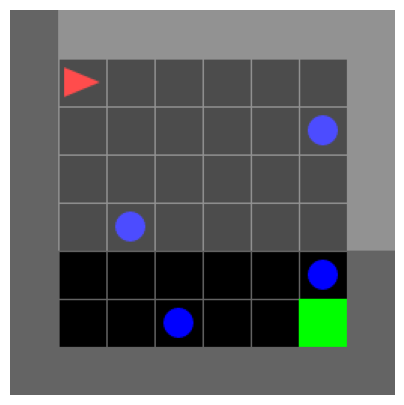